# G-Objaverse: 2D Depth → 3D Point Cloud 投影

這個 notebook 展示如何從 G-Objaverse 資料集的渲染影像和深度圖，反投影回 3D 點雲。

## 核心概念
- **內參矩陣 K**: 描述相機的焦距和主點位置
- **外參矩陣 c2w (camera-to-world)**: 描述相機在世界座標系中的位姿
- **深度圖**: 每個像素到相機的距離
- **反投影公式**: `P_world = c2w @ K^(-1) @ [u, v, 1]^T * depth`

## Step 1: 載入必要的函式庫

In [1]:
import numpy as np
import cv2
import json
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch

# 啟用 OpenEXR 支援
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

# 設定 matplotlib 顯示
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2: 定義核心函數

In [2]:
def get_intrinsic_matrix(height, width):
    """
    獲取相機內參矩陣 K
    
    G-Objaverse 使用固定焦距 fx=fy=1422.222 (基於 1024x1024 解析度)
    主點位於影像中心
    
    K = | fx  0  cx |
        | 0  fy  cy |
        | 0   0   1 |
    """
    fx = fy = 1422.222
    res_raw = 1024
    
    # 根據實際解析度縮放焦距
    f_x = f_y = fx * height / res_raw
    cx = width / 2
    cy = height / 2
    
    K = np.array([
        [f_x, 0, cx],
        [0, f_y, cy],
        [0, 0, 1]
    ], dtype=np.float32)
    
    return K


def read_camera_matrix(json_file):
    """
    讀取相機外參矩陣 (camera-to-world, c2w)
    
    JSON 檔案包含:
    - x: 相機 X 軸方向 (right)
    - y: 相機 Y 軸方向 (up)
    - z: 相機 Z 軸方向 (forward/backward)
    - origin: 相機位置
    
    注意: 需要 flip Y 和 Z 軸來轉換座標系統
    """
    with open(json_file, 'r', encoding='utf8') as f:
        data = json.load(f)
    
    c2w = np.eye(4, dtype=np.float32)
    c2w[:3, 0] = np.array(data['x'])       # X 軸
    c2w[:3, 1] = -np.array(data['y'])      # Y 軸 (flipped)
    c2w[:3, 2] = -np.array(data['z'])      # Z 軸 (flipped)
    c2w[:3, 3] = np.array(data['origin'])  # 相機位置
    
    return c2w


def read_depth_from_exr(exr_path, camera_position):
    """
    從 EXR 檔案讀取深度圖
    
    *_nd.exr 檔案格式:
    - Channel 0-2: Normal (世界座標系)
    - Channel 3: Depth
    
    深度值需要過濾掉 near plane 之前的無效值
    """
    # 計算相機距離原點的距離
    cam_distance = np.linalg.norm(camera_position)
    
    # near plane 設定 (物體被normalize到單位球內)
    near = 0.867  # sqrt(3) * 0.5
    near_distance = cam_distance - near
    
    # 讀取 EXR 檔案
    normald = cv2.imread(exr_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth = normald[..., 3]  # 第4個通道是深度
    
    # 過濾無效深度值
    depth[depth < near_distance] = 0
    
    return depth, normald[..., :3]  # 回傳深度和法向量


def read_rgb_image(img_path):
    """讀取 RGB 影像並轉換到 [0, 1] 範圍"""
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    
    # BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 處理 RGBA
    if img.shape[-1] == 4:
        img = img[..., :3]
    
    return img.astype(np.float32) / 255.0

print("Core functions defined!")

Core functions defined!


## Step 3: 2D → 3D 反投影函數 (核心！)

In [3]:
def unproject_depth_to_pointcloud(depth, K, c2w, rgb=None):
    """
    將深度圖反投影到 3D 世界座標點雲
    
    數學公式:
    1. 像素座標 (u, v) + depth → 相機座標 P_cam
       P_cam = K^(-1) @ [u, v, 1]^T * depth
    
    2. 相機座標 → 世界座標
       P_world = c2w @ [P_cam, 1]^T
    
    Args:
        depth: [H, W] 深度圖
        K: [3, 3] 內參矩陣
        c2w: [4, 4] camera-to-world 矩陣
        rgb: [H, W, 3] 可選的顏色圖
    
    Returns:
        points: [N, 3] 世界座標點雲
        colors: [N, 3] 對應的顏色 (如果有提供 rgb)
    """
    H, W = depth.shape
    
    # Step 1: 建立像素座標網格
    u = np.arange(W)
    v = np.arange(H)
    u, v = np.meshgrid(u, v)  # [H, W]
    
    # Step 2: 只取有效深度的點
    valid_mask = depth > 0
    u_valid = u[valid_mask]
    v_valid = v[valid_mask]
    depth_valid = depth[valid_mask]
    
    # Step 3: 像素座標 → 齊次座標
    # [u, v, 1]^T
    ones = np.ones_like(u_valid)
    pixel_coords = np.stack([u_valid, v_valid, ones], axis=0)  # [3, N]
    
    # Step 4: 反投影到相機座標系
    # P_cam = K^(-1) @ [u, v, 1]^T * depth
    K_inv = np.linalg.inv(K)
    cam_coords = K_inv @ pixel_coords  # [3, N]
    cam_coords = cam_coords * depth_valid[np.newaxis, :]  # 乘以深度
    
    # Step 5: 相機座標 → 世界座標
    # P_world = c2w @ [P_cam, 1]^T
    ones_row = np.ones((1, cam_coords.shape[1]))
    cam_coords_homo = np.vstack([cam_coords, ones_row])  # [4, N]
    world_coords = c2w @ cam_coords_homo  # [4, N]
    points = world_coords[:3, :].T  # [N, 3]
    
    # Step 6: 獲取顏色
    colors = None
    if rgb is not None:
        colors = rgb[valid_mask]  # [N, 3]
    
    return points, colors, valid_mask


def convert_pose_flip_yz(c2w):
    """
    Flip Y 和 Z 軸 (用於座標系統轉換)
    這是因為不同軟體使用不同的座標系統慣例
    """
    flip_yz = np.eye(4)
    flip_yz[1, 1] = -1
    flip_yz[2, 2] = -1
    return c2w @ flip_yz

print("Unprojection functions defined!")

Unprojection functions defined!


## Step 4: 設定資料路徑

⚠️ **請修改 `DATA_ROOT` 為你的實際資料路徑**

In [ ]:
# ===== 修改這裡的路徑 =====
# 下載範例資料: wget https://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/Lingtengqiu/render_data_examples.zip
DATA_ROOT = './campos_512_v4'  # 範例資料路徑

# 檢查路徑是否存在
if os.path.exists(DATA_ROOT):
    view_folders = sorted([f for f in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, f))])
    print(f"✓ Found {len(view_folders)} views in {DATA_ROOT}")
    print(f"  Views: {view_folders[:5]}... (showing first 5)")
else:
    print(f"✗ Path not found: {DATA_ROOT}")
    print("請下載範例資料或修改 DATA_ROOT 路徑")
    print("下載指令: wget https://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/Lingtengqiu/render_data_examples.zip")

✓ Found 40 views in ../../campos_512_v4
  Views: ['00000', '00001', '00002', '00003', '00004']... (showing first 5)


## Step 5: 讀取單一視角的資料並視覺化

Loading view 0...
  RGB: ../../campos_512_v4/00000/00000.png
  Depth: ../../campos_512_v4/00000/00000_nd.exr
  Camera: ../../campos_512_v4/00000/00000.json

Camera position: [1.3622161 0.        0.6657044]
Camera distance from origin: 1.516

Image shape: (512, 512, 3)
Depth shape: (512, 512)
Depth range: [0.653, 1.634]


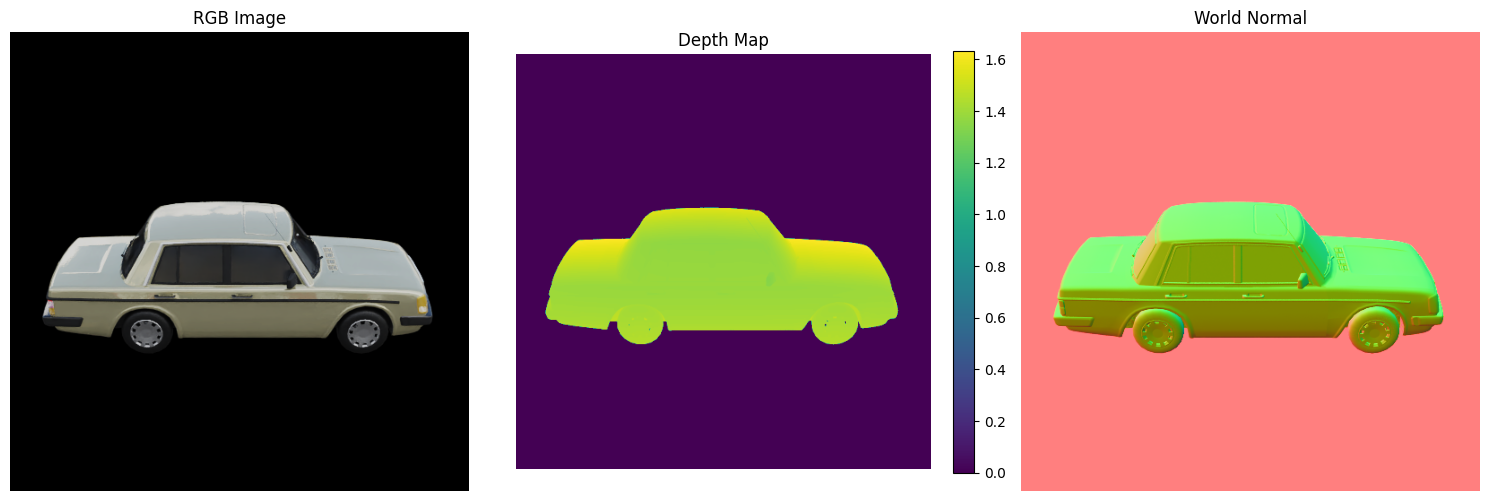

In [7]:
# 選擇要讀取的視角
VIEW_IDX = 0

# 建立檔案路徑
img_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.png'
depth_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}_nd.exr'
json_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.json'

print(f"Loading view {VIEW_IDX}...")
print(f"  RGB: {img_path}")
print(f"  Depth: {depth_path}")
print(f"  Camera: {json_path}")

# 讀取相機參數
c2w = read_camera_matrix(json_path)
camera_position = c2w[:3, 3]

print(f"\nCamera position: {camera_position}")
print(f"Camera distance from origin: {np.linalg.norm(camera_position):.3f}")

# 讀取 RGB 和深度
rgb = read_rgb_image(img_path)
depth, normal = read_depth_from_exr(depth_path, camera_position)

print(f"\nImage shape: {rgb.shape}")
print(f"Depth shape: {depth.shape}")
print(f"Depth range: [{depth[depth>0].min():.3f}, {depth[depth>0].max():.3f}]")

# 視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title('RGB Image')
axes[0].axis('off')

im = axes[1].imshow(depth, cmap='viridis')
axes[1].set_title('Depth Map')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# 法向量視覺化 (轉換到 [0, 1] 範圍)
normal_vis = (normal + 1) / 2
normal_vis = np.clip(normal_vis, 0, 1)
axes[2].imshow(normal_vis)
axes[2].set_title('World Normal')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 6: 將單一視角反投影到 3D 點雲

In [8]:
# 獲取內參矩陣
H, W = depth.shape
K = get_intrinsic_matrix(H, W)

print("Intrinsic Matrix K:")
print(K)
print(f"\nFocal length: fx={K[0,0]:.2f}, fy={K[1,1]:.2f}")
print(f"Principal point: cx={K[0,2]:.2f}, cy={K[1,2]:.2f}")

# 執行反投影
c2w_converted = convert_pose_flip_yz(c2w)
points, colors, valid_mask = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)

print(f"\nGenerated {len(points)} 3D points")
print(f"Point cloud bounds:")
print(f"  X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
print(f"  Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
print(f"  Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")

Intrinsic Matrix K:
[[711.111   0.    256.   ]
 [  0.    711.111 256.   ]
 [  0.      0.      1.   ]]

Focal length: fx=711.11, fy=711.11
Principal point: cx=256.00, cy=256.00

Generated 52606 3D points
Point cloud bounds:
  X: [-0.134, 0.815]
  Y: [-0.444, 0.438]
  Z: [-0.158, 0.429]


## Step 7: 視覺化單視角 3D 點雲

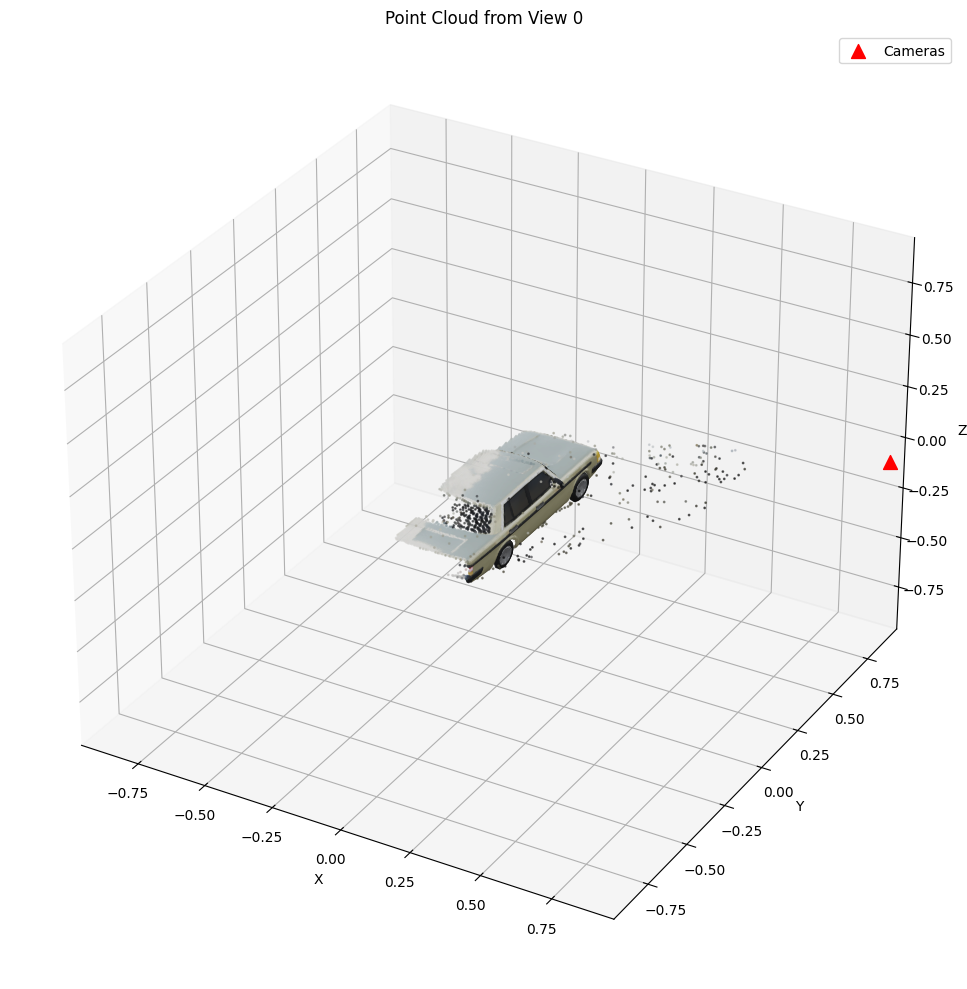

In [9]:
def visualize_point_cloud_3d(points, colors=None, title="Point Cloud", 
                              camera_positions=None, subsample=5):
    """
    使用 matplotlib 視覺化 3D 點雲
    
    Args:
        points: [N, 3] 點雲座標
        colors: [N, 3] 點的顏色
        camera_positions: list of [3,] 相機位置 (可選)
        subsample: 降採樣倍率 (加速視覺化)
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 降採樣以加速視覺化
    idx = np.arange(0, len(points), subsample)
    pts = points[idx]
    
    if colors is not None:
        cols = colors[idx]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   c=cols, s=1, alpha=0.6)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   s=1, alpha=0.6)
    
    # 繪製相機位置
    if camera_positions is not None:
        cam_pos = np.array(camera_positions)
        ax.scatter(cam_pos[:, 0], cam_pos[:, 1], cam_pos[:, 2],
                   c='red', s=100, marker='^', label='Cameras')
        ax.legend()
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # 設定相等的軸比例
    max_range = np.max(np.abs(pts)) * 1.2
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    plt.tight_layout()
    return fig, ax

# 視覺化單視角點雲
fig, ax = visualize_point_cloud_3d(
    points, colors, 
    title=f"Point Cloud from View {VIEW_IDX}",
    camera_positions=[camera_position],
    subsample=3
)
plt.show()

## Step 8: 合併多個視角的點雲

In [32]:
def load_all_views(data_root, num_views=40):
    """
    載入所有視角的資料並合併成完整點雲
    
    Args:
        data_root: 資料根目錄
        num_views: 視角數量 (預設 40)
    
    Returns:
        all_points: 合併的點雲
        all_colors: 對應的顏色
        camera_positions: 所有相機位置
    """
    all_points = []
    all_colors = []
    camera_positions = []
    
    for view_idx in range(num_views):
        # 檔案路徑
        img_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.png'
        depth_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}_nd.exr'
        json_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.json'
        
        # 檢查檔案是否存在
        if not all(os.path.exists(p) for p in [img_path, depth_path, json_path]):
            print(f"  Skipping view {view_idx} (files not found)")
            continue
        
        # 讀取資料
        c2w = read_camera_matrix(json_path)
        camera_pos = c2w[:3, 3]
        
        rgb = read_rgb_image(img_path)
        depth, _ = read_depth_from_exr(depth_path, camera_pos)
        
        # 內參
        H, W = depth.shape
        K = get_intrinsic_matrix(H, W)
        
        # 反投影
        c2w_converted = convert_pose_flip_yz(c2w)
        points, colors, _ = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)
        
        all_points.append(points)
        all_colors.append(colors)
        camera_positions.append(camera_pos)
        
        if (view_idx + 1) % 10 == 0:
            print(f"  Loaded {view_idx + 1}/{num_views} views")
    
    # 合併
    all_points = np.vstack(all_points)
    all_colors = np.vstack(all_colors)
    camera_positions = np.array(camera_positions)
    
    return all_points, all_colors, camera_positions


# 載入多個視角 (這裡只載入前 8 個視角作為示範，可調整)
NUM_VIEWS_TO_LOAD = 24  # 可以改成 40 載入所有視角

print(f"Loading {NUM_VIEWS_TO_LOAD} views...")
all_points, all_colors, all_camera_positions = load_all_views(DATA_ROOT, NUM_VIEWS_TO_LOAD)

print(f"\n=== Summary ===")
print(f"Total points: {len(all_points):,}")
print(f"Total cameras: {len(all_camera_positions)}")

Loading 24 views...
  Loaded 10/24 views
  Loaded 20/24 views

=== Summary ===
Total points: 1,143,909
Total cameras: 24


## Step 9: 視覺化合併後的完整點雲

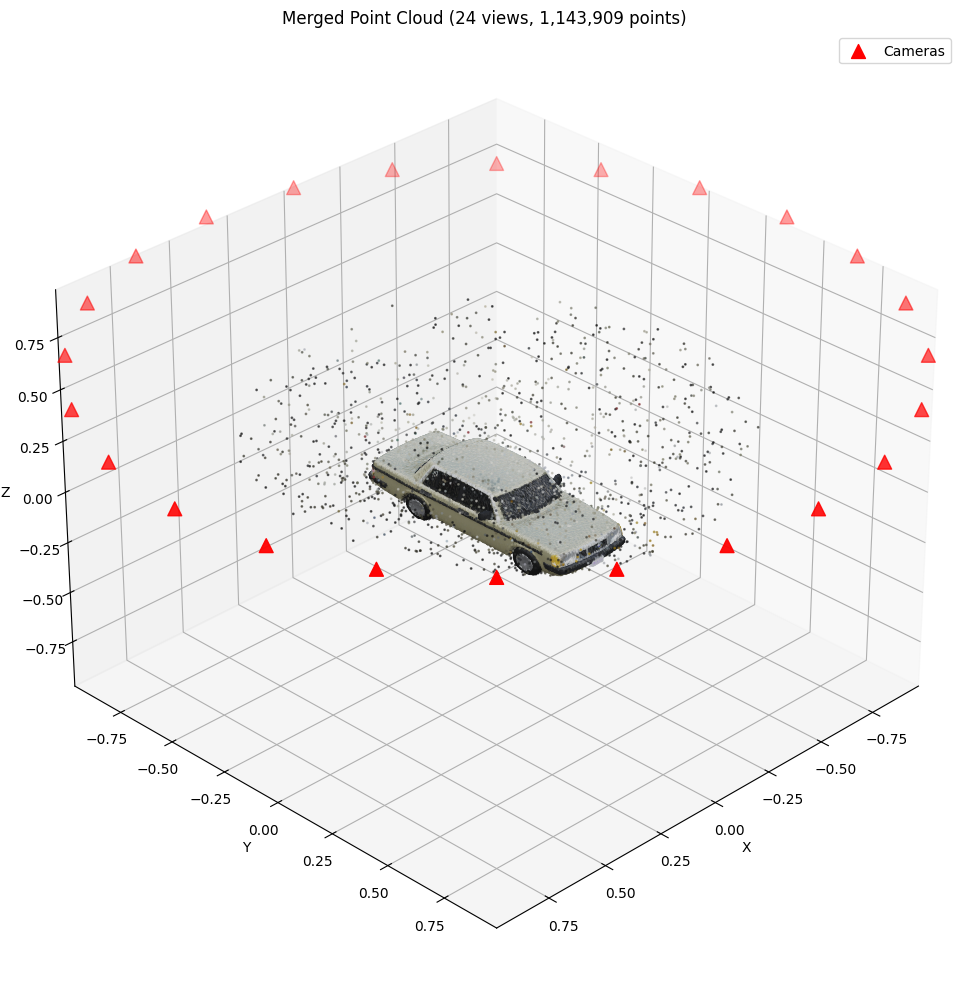

In [33]:
# 視覺化完整點雲
fig, ax = visualize_point_cloud_3d(
    all_points, all_colors,
    title=f"Merged Point Cloud ({NUM_VIEWS_TO_LOAD} views, {len(all_points):,} points)",
    camera_positions=all_camera_positions,
    subsample=10  # 降採樣倍率
)

# 可以旋轉視角
ax.view_init(elev=30, azim=45)
plt.show()

## Step 10: 互動式 3D 視覺化 (使用 plotly)

In [34]:
# 可選: 使用 plotly 進行互動式視覺化
try:
    import plotly.graph_objects as go
    
    # 降採樣
    subsample = 20
    idx = np.arange(0, len(all_points), subsample)
    pts = all_points[idx]
    cols = all_colors[idx]
    
    # 將顏色轉換為 plotly 格式
    colors_rgb = ['rgb({},{},{})'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255)) 
                  for c in cols]
    
    fig = go.Figure()
    
    # 點雲
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=1, color=colors_rgb),
        name='Point Cloud'
    ))
    
    # 相機位置
    fig.add_trace(go.Scatter3d(
        x=all_camera_positions[:, 0],
        y=all_camera_positions[:, 1],
        z=all_camera_positions[:, 2],
        mode='markers',
        marker=dict(size=5, color='red', symbol='diamond'),
        name='Cameras'
    ))
    
    fig.update_layout(
        title=f"Interactive Point Cloud ({len(pts):,} points displayed)",
        scene=dict(
            aspectmode='data',
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=900,
        height=700
    )
    
    fig.show()
    
except ImportError:
    print("Plotly not installed. Run: pip install plotly")
    print("Skipping interactive visualization.")

## Step 11: 儲存點雲為 PLY 檔案

In [ ]:
def save_point_cloud_ply(filename, points, colors=None):
    """
    將點雲儲存為 PLY 格式
    可以用 MeshLab, CloudCompare, Open3D 等軟體開啟
    """
    num_points = len(points)
    
    with open(filename, 'w') as f:
        # PLY header
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {num_points}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        if colors is not None:
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
        f.write("end_header\n")
        
        # 寫入點資料
        for i in range(num_points):
            line = f"{points[i, 0]:.6f} {points[i, 1]:.6f} {points[i, 2]:.6f}"
            if colors is not None:
                r, g, b = (colors[i] * 255).astype(np.uint8)
                line += f" {r} {g} {b}"
            f.write(line + "\n")
    
    print(f"Saved {num_points:,} points to {filename}")


# 儲存點雲
output_path = "./point_cloud_output.ply"
save_point_cloud_ply(output_path, all_points, all_colors)
print(f"\n可以用 MeshLab 或 CloudCompare 開啟 {output_path} 檢視完整點雲")

## 總結: 投影變換數學公式

### 2D → 3D 反投影 (Unprojection)

```
給定:
- 像素座標 (u, v)
- 深度值 d
- 內參矩陣 K
- 外參矩陣 c2w (camera-to-world)

Step 1: 像素 → 相機座標
P_cam = K^(-1) @ [u, v, 1]^T * d

Step 2: 相機座標 → 世界座標  
P_world = c2w @ [P_cam, 1]^T
```

### 3D → 2D 投影 (Projection)

```
給定:
- 世界座標點 P_world = [X, Y, Z]^T
- 內參矩陣 K
- 外參矩陣 w2c (world-to-camera) = c2w^(-1)

Step 1: 世界座標 → 相機座標
P_cam = w2c @ [P_world, 1]^T

Step 2: 相機座標 → 像素座標 (透視投影)
[u', v', w'] = K @ P_cam
u = u' / w'
v = v' / w'
```